<a href="https://colab.research.google.com/github/Mia-NK/Mia_INFO4670_Fall2026/blob/main/INFO_4670_Assignment_3_%5BASSOCIATION_RULE_MINING%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Dataset:** `bread_basket.csv` (11569 transactions)

Fill in the short answer cells and run the code cells. This notebook generates the required tables and figures.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt


## 1) Setup & Data Load (10 pts)
- Place `bread_basket.csv` in the same folder as this notebook **or** update the path below.
- Needed packages: `pandas`, `matplotlib`, `mlxtend`, `networkx` (for the small graph).
- If a package is missing, run the `pip install` cell.

In [137]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
import networkx as nx

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [139]:
basket = pd.read_csv('bread_basket.csv')
basket.head() #checking import

,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend


In [140]:
display(basket.columns, basket.dtypes) #variables and dtypes

Index(['transaction', 'item', 'date_time', 'time', 'period_day',
       'weekday_weekend'],
      dtype='object')

,0
transaction,int64
item,object
date_time,object
time,object
period_day,object
weekday_weekend,object


### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [141]:
basket.describe(include='all')

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202370,NaN,NaN,NaN,NaN,NaN
std,2796.203001,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN
25%,2552.000000,NaN,NaN,NaN,NaN,NaN
50%,5137.000000,NaN,NaN,NaN,NaN,NaN
75%,7357.000000,NaN,NaN,NaN,NaN,NaN


### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

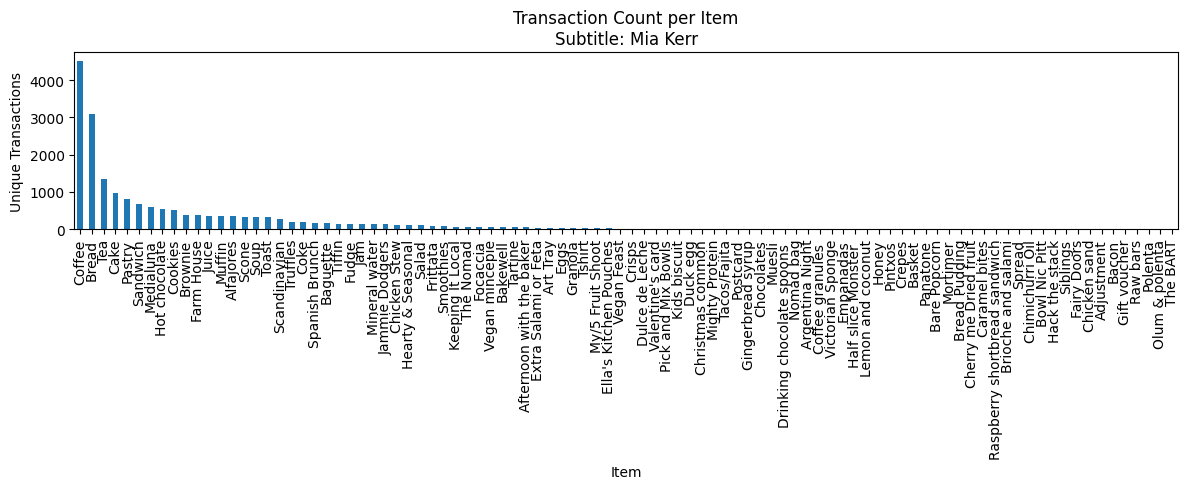

In [142]:
# c) Bar plot of transaction counts per item
subtitle = "Mia Kerr"  # <-- EDIT THIS
item_counts = (basket.groupby('item')['transaction'].nunique()
              ).sort_values(ascending=False) # <-- EDIT THIS

ax = item_counts.plot(kind='bar', figsize=(12,5))
plt.title(f"Transaction Count per Item\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("Unique Transactions")
plt.tight_layout()
plt.show()

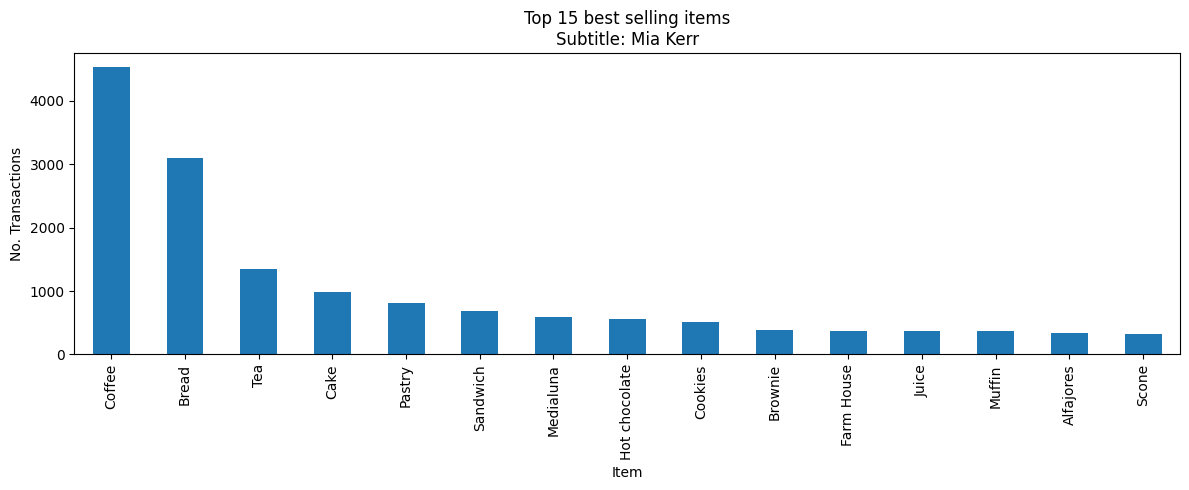

In [143]:
top15 = item_counts.head(15) #already sorted so we can just grab the head

ax = top15.plot(kind='bar', figsize=(12,5))
plt.title(f"Top 15 best selling items\nSubtitle: {subtitle}")
plt.xlabel("Item"); plt.ylabel("No. Transactions")
plt.tight_layout()
plt.show()
#added this for more visual clarity since the first graph has a lot of data with
# low or zero value_counts()

### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [153]:
sublist = ['Coffee', 'Tea', 'Alfajores', 'Juice', 'Chicken Stew']
count_sublist = basket.groupby('item')['transaction'].nunique()[sublist]
count_sublist
#not sure if we want total transactions or unique - rule has been unqiue so far
# so I went with that

,transaction
item,
Coffee,4528
Tea,1350
Alfajores,344
Juice,365
Chicken Stew,123


## 3) Frequent Itemset Mining with FP‑Growth (min_support = 0.02) (20 pts)
We pivot the data to a **transaction × item** one‑hot table (boolean), then run FP‑Growth.

In [145]:
te = TransactionEncoder()
te_ary = te.fit(basket.groupby('transaction')['item'].apply(list)).transform(
         basket.groupby('transaction')['item'].apply(list))
oht = pd.DataFrame(te_ary, columns=te.columns_)
oht.head()

,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [146]:
freq_fp = fpgrowth(oht, min_support=0.02, use_colnames=True)
rules_fp = association_rules(freq_fp, metric='confidence', min_threshold=0.5)
rules_fp[['antecedents','consequents','support','confidence',
          'lift']].sort_values('confidence', ascending=False)

,antecedents,consequents,support,confidence,lift
7,(Toast),(Coffee),0.023666,0.704403,1.472431
3,(Medialuna),(Coffee),0.035182,0.569231,1.189878
2,(Pastry),(Coffee),0.047544,0.552147,1.154168
4,(Juice),(Coffee),0.020602,0.534247,1.116750
6,(Sandwich),(Coffee),0.038246,0.532353,1.112792
5,(Cake),(Coffee),0.054728,0.526958,1.101515
1,(Cookies),(Coffee),0.028209,0.518447,1.083723
0,(Hot chocolate),(Coffee),0.029583,0.507246,1.060311


## 4) Association Rules + Report Table (30 pts)
(metric = confidence, min_threshold = ?) Please find a suitable min_threshold

In [147]:
rules_fp = association_rules(freq_fp, metric='confidence', min_threshold=0.4)
#40% conf threshold
rules_fp[['antecedents','consequents','support',
          'confidence','lift']].sort_values('confidence', ascending=False)

,antecedents,consequents,support,confidence,lift
7,(Toast),(Coffee),0.023666,0.704403,1.472431
3,(Medialuna),(Coffee),0.035182,0.569231,1.189878
2,(Pastry),(Coffee),0.047544,0.552147,1.154168
4,(Juice),(Coffee),0.020602,0.534247,1.116750
6,(Sandwich),(Coffee),0.038246,0.532353,1.112792
5,(Cake),(Coffee),0.054728,0.526958,1.101515
1,(Cookies),(Coffee),0.028209,0.518447,1.083723
0,(Hot chocolate),(Coffee),0.029583,0.507246,1.060311


## 5) Interpretation (10 pts)
**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support**: What fraction of *all* transactions contain Coffee, Cake, and Bread together?
- **Confidence**: Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

*Your notes:*

The rule {Coffee, Cake} ⇒ {Bread} suggests that a transaction containing both coffee and cake (the antecedents) will correlate with an additional purchase of bread (the consequent). TLDR, buying coffee and cake together will lead to buying bread as well.

- SUPPORT: The support for {Coffee, Cake, Bread} is 0.01, meaning only 1% of all transactions contained these three items together
- CONFIDENCE: The confidence is ~18%, making this largely unremarkable by most minconf standards
- LIFT: The lift is 0.56; because it's less than 1, we have a slightly negative relationship between the consequent and its antecedents. A lift > 1 indicates reliability in pairing/associating antecedent(s) and consequent(s), allowing for reliable decision-making using their relationship

In [148]:
#can't answer prev section without doing the math so I have that here
length = basket['transaction'].unique()
rulesets = basket.groupby('transaction')['item'].apply(set)

count_antedent = rulesets.apply(lambda s: {'Coffee', 'Cake'}.issubset(s)).sum
count_rule = rulesets.apply(lambda s: {'Coffee', 'Cake', 'Bread'}.issubset(s)).sum
count_consequent = rulesets.apply(lambda s: 'Bread' in s).sum

support_rule = count_rule() / len(length)
support_antecedent = count_antedent() / len(length)
support_consequent = count_consequent() / len(length)

confidence = support_rule / support_antecedent
lift = confidence / support_consequent

print("Support:", support_rule.round(2))
print("Confidence:", confidence.round(2))
print("Lift:", lift.round(2))

Support: 0.01
Confidence: 0.18
Lift: 0.56


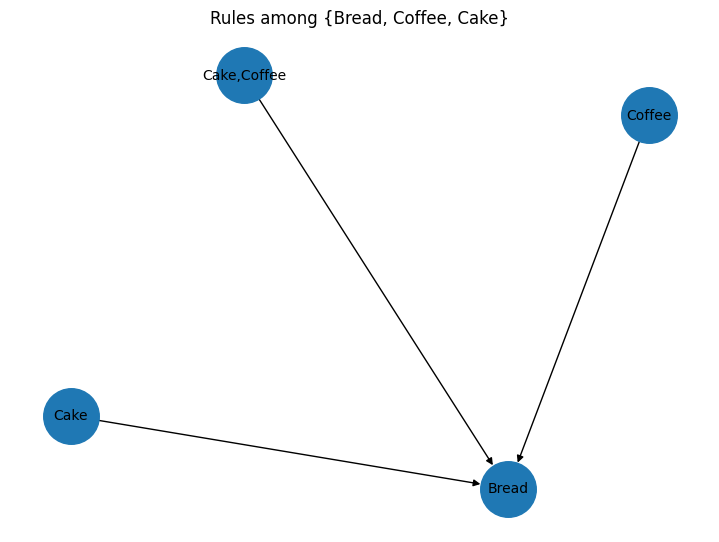

In [149]:
G = nx.DiGraph()
for _, r in sub.iterrows():
    a = ','.join(sorted(list(r['antecedents'])))
    c = ','.join(sorted(list(r['consequents'])))
    G.add_edge(a, c, weight=float(r['confidence']), lift=float(r['lift']))

plt.figure(figsize=(7,5))
pos = nx.spring_layout(G, seed=0)
nx.draw(G, pos, with_labels=True, node_size=1600, font_size=10, arrows=True)
plt.title("Rules among {Bread, Coffee, Cake}")
plt.show()

#in the directions for this notebook it says there are 6 sections where sec. 5
# is the subgraph for the rules. There are only 5 sections and no explicit
# directions to cerate a subgraph but here's one anyway since it was mentioned
# in the beginning

In [150]:
#I'm curious to see if the low support for {Coffee, cake, bread} is due to the
# cake since coffee and bread seem like they should be extremely regular purchases
# so just testing on the side for fun

cat = rulesets.apply(lambda s: {'Coffee', 'Bread'}.issubset(s)).sum
print("curiosity killed the cat:", (cat()/len(length)).round(2))

curiosity killed the cat: 0.09
